# Trabalho Final - notebook base do projeto da Kauany

In [1]:
# Bibliotecas usadas ao longo do notebook: pandas para manipulacao de dados,
# matplotlib para os graficos e seaborn para estetica dos graficos
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

## Pergunta de pesquisa

#### **Quais fatores comportamentais e sociodemográficos estão mais associados aos diferentes níveis de obesidade?**

(nível de obesidade, frequência de atividade física, consumo frequente de alimentos calóricos, consumo de alimentos entre as refeições, meio de transporte, gênero, idade, histórico familiar de sobrepeso)

--- A obesidade é uma condição associada a fatores genéticos, comportamentais e sociais, e entender quais desses fatores mais se associam aos diferentes níveis de obesidade é relevante para pensar políticas de saúde pública. Neste trabalho será utilizado o conjunto de dados *Obesity*, publicado por Palechor, F. M., & de la Hoz Manotas, A. (2019). "Dataset for estimation of obesity levels based on eating habits and physical condition in individuals from Colombia, Peru and Mexico". *Data in Brief*, 25, 104344. https://doi.org/10.1016/j.dib.2019.104344 — também disponível no [UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/544/estimation+of+obesity+levels+based+on+eating+habits+and+physical+condition). O dataset reúne 2.111 registros de pessoas da Colômbia, Peru e México, com informações sobre hábitos alimentares, atividade física e características sociodemográficas, além do nível de obesidade de cada pessoa (classificado em 7 categorias, do peso insuficiente à obesidade Tipo III). Pretende-se avaliar como fatores comportamentais — frequência de atividade física, consumo de alimentos calóricos, consumo de alimentos entre as refeições e meio de transporte — e fatores sociodemográficos/hereditários — gênero, idade e histórico familiar de sobrepeso — se associam ao grau de obesidade, sem supor de antemão qual desses fatores é o mais relevante.

In [2]:
# Carrega o dataset a partir do zip (contem um unico CSV) e mostra as primeiras linhas
# para uma primeira inspecao visual das colunas e valores
df = pd.read_csv("../datasets/kauany/Obesity.zip", compression='zip')

df.head()

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
0,Female,21.0,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight
1,Female,21.0,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight
2,Male,23.0,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight
3,Male,27.0,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I
4,Male,22.0,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II


In [3]:
# Lista todas as colunas disponiveis no dataset
df.columns

Index(['Gender', 'Age', 'Height', 'Weight', 'family_history', 'FAVC', 'FCVC',
       'NCP', 'CAEC', 'SMOKE', 'CH2O', 'SCC', 'FAF', 'TUE', 'CALC', 'MTRANS',
       'Obesity'],
      dtype='str')

## Classificação das variáveis associadas à pergunta de pesquisa

In [4]:
# Nivel de obesidade: variavel-alvo da pergunta de pesquisa
df["Obesity"].unique()

<StringArray>
[      'Normal_Weight',  'Overweight_Level_I', 'Overweight_Level_II',
      'Obesity_Type_I', 'Insufficient_Weight',     'Obesity_Type_II',
    'Obesity_Type_III']
Length: 7, dtype: str

A variável **Obesity** é **categórica** e possui 7 categorias, que seguem a classificação clínica padrão de IMC (peso/altura²) da OMS: Insufficient_Weight, Normal_Weight, Overweight_Level_I, Overweight_Level_II, Obesity_Type_I, Obesity_Type_II e Obesity_Type_III. É a variável-alvo da pergunta de pesquisa — os "diferentes níveis de obesidade".

In [5]:
# Frequencia de atividade fisica (fator comportamental)
df["FAF"].unique()

array([0.      , 3.      , 2.      , ..., 1.414209, 1.139107, 1.026452],
      shape=(1190,))

A variável **FAF** (Frequência de Atividade Física) é **numérica** e varia de 0 a 3 no dataset. No questionário original que deu origem a este dataset (Palechor & de la Hoz Manotas, 2019), essa pergunta era respondida em uma escala de 4 categorias (0 = nenhuma, 1 = 1 a 2 dias/semana, 2 = 2 a 4 dias/semana, 3 = 4 a 5 dias/semana); os valores aqui aparecem contínuos porque 77% deste dataset foi gerado por sobre-amostragem sintética (SMOTE) a partir dos 23% de respostas reais coletadas na plataforma web, conforme descrito pelos próprios autores do dataset.

In [6]:
# Consumo frequente de alimentos com alto teor calorico (fator comportamental)
df["FAVC"].unique()

<StringArray>
['no', 'yes']
Length: 2, dtype: str

A variável **FAVC** (consumo frequente de alimentos calóricos) é **categórica** e possui 2 categorias (yes/no).

In [7]:
# Consumo de alimentos entre as principais refeicoes (fator comportamental)
df["CAEC"].unique()

<StringArray>
['Sometimes', 'Frequently', 'Always', 'no']
Length: 4, dtype: str

A variável **CAEC** (consumo de alimentos entre as refeições) é **categórica** e possui 4 categorias: no, Sometimes, Frequently, Always.

In [8]:
# Meio de transporte mais usado (fator comportamental)
df["MTRANS"].unique()

<StringArray>
['Public_Transportation', 'Walking', 'Automobile', 'Motorbike', 'Bike']
Length: 5, dtype: str

A variável **MTRANS** (meio de transporte) é **categórica** e possui 5 categorias: Public_Transportation, Walking, Automobile, Motorbike, Bike.

In [9]:
# Genero (fator sociodemografico)
df["Gender"].unique()

<StringArray>
['Female', 'Male']
Length: 2, dtype: str

A variável **Gender** é **categórica** e possui 2 categorias (Female/Male).

In [10]:
# Idade (fator sociodemografico)
df["Age"].unique()

array([21.      , 23.      , 27.      , ..., 22.524036, 24.361936,
       23.664709], shape=(1402,))

A variável **Age** é **numérica** e varia de 14 a 61 anos no dataset.

In [11]:
# Historico familiar de sobrepeso (fator hereditario/sociodemografico)
df["family_history"].unique()

<StringArray>
['yes', 'no']
Length: 2, dtype: str

A variável **family_history** (histórico familiar de sobrepeso) é **categórica** e possui 2 categorias (yes/no). Não é estritamente um dado sociodemográfico (é autorreferido e de natureza hereditária), mas é tratada aqui junto aos fatores sociodemográficos por não ser um comportamento que a própria pessoa controla no dia a dia, ao contrário de FAF, FAVC, CAEC e MTRANS.

## Verificando a qualidade dos dados

In [12]:
# Verificando se ha duplicatas
df.duplicated().sum()

np.int64(24)

In [13]:
# Se houver dados duplicados, verificamos quais sao
df[df.duplicated()]

,Gender,Age,Height,Weight,family_history,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,Obesity
98,Female,21.0,1.52,42.0,no,no,3.0,1.0,Frequently,no,1.0,no,0.0,0.0,Sometimes,Public_Transportation,Insufficient_Weight
106,Female,25.0,1.57,55.0,no,yes,2.0,1.0,Sometimes,no,2.0,no,2.0,0.0,Sometimes,Public_Transportation,Normal_Weight
174,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
179,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
184,Male,21.0,1.62,70.0,no,yes,2.0,1.0,no,no,3.0,no,1.0,0.0,Sometimes,Public_Transportation,Overweight_Level_I
209,Female,22.0,1.69,65.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,1.0,1.0,Sometimes,Public_Transportation,Normal_Weight
309,Female,16.0,1.66,58.0,no,no,2.0,1.0,Sometimes,no,1.0,no,0.0,1.0,no,Walking,Normal_Weight
460,Female,18.0,1.62,55.0,yes,yes,2.0,3.0,Frequently,no,1.0,no,1.0,1.0,no,Public_Transportation,Normal_Weight
467,Male,22.0,1.74,75.0,yes,yes,3.0,3.0,Frequently,no,1.0,no,1.0,0.0,no,Automobile,Normal_Weight
496,Male,18.0,1.72,53.0,yes,yes,2.0,3.0,Sometimes,no,2.0,no,0.0,2.0,Sometimes,Public_Transportation,Insufficient_Weight


**Conclusão 1:** há 24 linhas duplicadas no dataset (registros idênticos em todas as colunas), o que corresponde a cerca de 1,1% do total de 2.111 registros.

In [14]:
# Verificando se ha valores faltantes (soma e porcentagem por coluna)
dados_faltantes_soma = df.isnull().sum()
dados_faltantes_porc = df.isnull().mean() * 100

df_dados_faltantes = pd.DataFrame({"Dados faltantes (soma)": dados_faltantes_soma, "Dados faltantes (porcentagem)": dados_faltantes_porc})
df_dados_faltantes

,Dados faltantes (soma),Dados faltantes (porcentagem)
Gender,0,0.0
Age,0,0.0
Height,0,0.0
Weight,0,0.0
family_history,0,0.0
FAVC,0,0.0
FCVC,0,0.0
NCP,0,0.0
CAEC,0,0.0
SMOKE,0,0.0


**Conclusão 2:** não há nenhum valor faltante em nenhuma coluna do dataset. Portanto, a limpeza não vai precisar remover nem imputar dados por esse motivo.

## Limpeza do conjunto de dados

In [15]:
# Remove as linhas duplicadas identificadas acima
df = df.drop_duplicates()

df.shape

(2087, 17)

**Conclusão 3:** a limpeza removeu as 24 linhas duplicadas, restando 2.087 registros. Não foi preciso tratar valores faltantes (Conclusão 2) nem unificar categorias de texto, porque as categorias de cada variável (checadas na seção anterior) já aparecem escritas de forma única e consistente, sem grafias duplicadas.

## Estatística descritiva

A variável-alvo (Obesity) é categórica, o que impede calcular sua "média" diretamente em um `groupby`. Para comparar os grupos numericamente, esta seção primeiro deriva o **IMC** (Índice de Massa Corporal = peso em kg / altura em m²) a partir das colunas `Weight` e `Height`, que já existem no dataset. O IMC não é um fator novo nem um substituto de outra variável pedida na pergunta: é a própria fórmula clínica que define as 7 categorias de Obesity, então usá-lo como variável numérica de comparação é uma forma direta (e não uma suposição) de medir o grau de obesidade em cada grupo.

In [16]:
# Calcula o IMC (peso / altura^2), a formula clinica por tras da classificacao "Obesity"
df["BMI"] = df["Weight"] / (df["Height"] ** 2)

# Ordem clinica das 7 categorias, da mais leve a mais grave
ordem_obesity = ["Insufficient_Weight", "Normal_Weight", "Overweight_Level_I", "Overweight_Level_II",
                  "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"]

# Valida que o IMC calculado acompanha a classificacao oficial de Obesity: espera-se
# que a media de IMC cresca do grupo Insufficient_Weight ate o Obesity_Type_III
media_imc_por_obesity = df.groupby("Obesity", observed=True)["BMI"].mean().reindex(ordem_obesity)
print("Média de IMC por nível de Obesity (validação):")
print(media_imc_por_obesity)
print("\nQuantidade de pessoas por nível de Obesity:")
print(df["Obesity"].value_counts().reindex(ordem_obesity))

Média de IMC por nível de Obesity (validação):
Obesity
Insufficient_Weight    17.390730
Normal_Weight          22.007841
Overweight_Level_I     25.956179
Overweight_Level_II    28.215232
Obesity_Type_I         32.255636
Obesity_Type_II        36.723424
Obesity_Type_III       42.273746
Name: BMI, dtype: float64

Quantidade de pessoas por nível de Obesity:
Obesity
Insufficient_Weight    267
Normal_Weight          282
Overweight_Level_I     276
Overweight_Level_II    290
Obesity_Type_I         351
Obesity_Type_II        297
Obesity_Type_III       324
Name: count, dtype: int64


**Nota metodológica:** a média de IMC cresce de forma monotônica do grupo Insufficient_Weight (17,39) até o Obesity_Type_III (42,27), confirmando que o IMC calculado reproduz fielmente a gradação de gravidade que a variável Obesity representa. Os 7 grupos têm tamanhos parecidos (267 a 351 pessoas cada), então nenhuma das médias por nível de Obesity é baseada em amostra pequena. A partir daqui, o IMC é usado como a variável numérica para comparar os fatores comportamentais e sociodemográficos entre si.

In [17]:
# Esta celula cria faixas (variaveis categoricas) a partir de "FAF" e "Age", que sao
# numericas, para poder comparar grupos de pessoas com groupby() nas celulas seguintes
# - do mesmo jeito que ja fazemos com as variaveis categoricas originais
#
# Para "FAF" existe a propria escala do questionario original do dataset (Palechor &
# de la Hoz Manotas, 2019): 0 = nenhuma atividade, 1 = 1 a 2 dias/semana, 2 = 2 a 4
# dias/semana, 3 = 4 a 5 dias/semana. Os valores continuos vem da geracao sintetica
# (SMOTE) explicada na classificacao de variaveis, entao arredondamos para o inteiro
# mais proximo antes de aplicar essa escala
#
# Para "Age" nao existe um padrao de faixa etaria especifico para obesidade aplicavel
# a esta amostra (nao e um recorte pediatrico nem geriatrico), entao dividimos em
# tercis (3 grupos de tamanho parecido) pelos proprios dados

# Reconstroi a escala original de 4 pontos do questionario a partir do valor continuo
df["Faixa_FAF"] = df["FAF"].round().astype(int).clip(0, 3).map({
    0: "0 - Nenhuma",
    1: "1 - 1 a 2 dias/sem",
    2: "2 - 2 a 4 dias/sem",
    3: "3 - 4 a 5 dias/sem",
})

# Tercis de idade: cada faixa reune ~1/3 das pessoas da amostra
df["Faixa_Idade"], cortes_idade = pd.qcut(df["Age"], q=3,
                                           labels=["14 a 21 anos", "21 a 26 anos", "26 a 61 anos"],
                                           retbins=True)

# Mostra os cortes numericos e quantas pessoas cairam em cada faixa, ja que os
# rotulos sozinhos nao deixam isso explicito
print(f"Cortes dos tercis de idade: {cortes_idade[0]:.0f}-{cortes_idade[1]:.1f}, "
      f"{cortes_idade[1]:.1f}-{cortes_idade[2]:.1f}, {cortes_idade[2]:.1f}-{cortes_idade[3]:.0f} anos")

print("\nPessoas por faixa de FAF:")
print(df["Faixa_FAF"].value_counts().sort_index())

print("\nPessoas por faixa de idade (tercis):")
print(df["Faixa_Idade"].value_counts().sort_index())

Cortes dos tercis de idade: 14-21.0, 21.0-25.5, 25.5-61 anos

Pessoas por faixa de FAF:
Faixa_FAF
0 - Nenhuma           714
1 - 1 a 2 dias/sem    759
2 - 2 a 4 dias/sem    495
3 - 4 a 5 dias/sem    119
Name: count, dtype: int64

Pessoas por faixa de idade (tercis):
Faixa_Idade
14 a 21 anos    749
21 a 26 anos    642
26 a 61 anos    696
Name: count, dtype: int64


In [18]:
# Calcula a media de IMC em cada faixa de frequencia de atividade fisica (FAF),
# para ver se praticar atividade fisica com mais frequencia esta associado a menor IMC

df_med_faf = df.groupby("Faixa_FAF", observed=True)[["BMI"]].mean()

print("Média de IMC por faixa de FAF:")
print(df_med_faf)

print("\n################################\n")

print("Maior média encontrada em cada variável:")
print(df_med_faf.max())
print("\nFaixa de FAF correspondente à maior média:")
print(df_med_faf.idxmax())

print("\n################################\n")

print("Menor média encontrada em cada variável:")
print(df_med_faf.min())
print("\nFaixa de FAF correspondente à menor média:")
print(df_med_faf.idxmin())

Média de IMC por faixa de FAF:
                          BMI
Faixa_FAF                    
0 - Nenhuma         31.112937
1 - 1 a 2 dias/sem  30.024793
2 - 2 a 4 dias/sem  28.518855
3 - 4 a 5 dias/sem  25.217222

################################

Maior média encontrada em cada variável:
BMI    31.112937
dtype: float64

Faixa de FAF correspondente à maior média:
BMI    0 - Nenhuma
dtype: str

################################

Menor média encontrada em cada variável:
BMI    25.217222
dtype: float64

Faixa de FAF correspondente à menor média:
BMI    3 - 4 a 5 dias/sem
dtype: str


**Conclusão 4:** usando a escala original do questionário (0 = nenhuma atividade a 3 = 4 a 5 dias por semana), o IMC médio cai de forma praticamente monotônica conforme a frequência de atividade física aumenta: 31,11 (Nenhuma) → 30,02 (1 a 2 dias/sem) → 28,52 (2 a 4 dias/sem) → 25,22 (4 a 5 dias/sem). A diferença entre o grupo menos ativo e o mais ativo é de quase 6 pontos de IMC, associando mais atividade física a menor grau de obesidade nesta amostra.

In [19]:
# Calcula a media de IMC em cada faixa de idade (tercis),
# para ver se pessoas mais velhas tendem a ter maior IMC nesta amostra

df_med_idade = df.groupby("Faixa_Idade", observed=True)[["BMI"]].mean()

print("Média de IMC por faixa de idade:")
print(df_med_idade)

print("\n################################\n")

print("Maior média encontrada em cada variável:")
print(df_med_idade.max())
print("\nFaixa de idade correspondente à maior média:")
print(df_med_idade.idxmax())

print("\n################################\n")

print("Menor média encontrada em cada variável:")
print(df_med_idade.min())
print("\nFaixa de idade correspondente à menor média:")
print(df_med_idade.idxmin())

Média de IMC por faixa de idade:
                    BMI
Faixa_Idade            
14 a 21 anos  25.701588
21 a 26 anos  30.554636
26 a 61 anos  33.411742

################################

Maior média encontrada em cada variável:
BMI    33.411742
dtype: float64

Faixa de idade correspondente à maior média:
BMI    26 a 61 anos
dtype: category
Categories (3, str): ['14 a 21 anos' < '21 a 26 anos' < '26 a 61 anos']

################################

Menor média encontrada em cada variável:
BMI    25.701588
dtype: float64

Faixa de idade correspondente à menor média:
BMI    14 a 21 anos
dtype: category
Categories (3, str): ['14 a 21 anos' < '21 a 26 anos' < '26 a 61 anos']


**Conclusão 5:** dividindo a idade em tercis (14 a 21, 21 a 26 e 26 a 61 anos — cada faixa com cerca de um terço da amostra, já que não existe uma faixa etária padrão para obesidade aplicável a esta amostra), o IMC médio cresce com a idade: 25,70 no tercil mais jovem, 30,55 no intermediário e 33,41 no mais velho — uma diferença de quase 8 pontos entre o tercil mais jovem e o mais velho. Essa é a maior diferença entre extremos encontrada até agora, mas vale registrar que idade e composição corporal têm uma relação biológica direta (o corpo tende a acumular mais gordura com o avanço da idade), então essa associação é, em parte, esperada e não necessariamente aponta para um "fator de risco comportamental".

In [20]:
# Calcula a media de IMC por consumo frequente de alimentos caloricos (FAVC),
# para ver se quem consome esses alimentos com frequencia tem IMC maior

df_med_favc = df.groupby("FAVC", observed=True)[["BMI"]].mean()

print("Média de IMC por FAVC (consumo frequente de alimentos calóricos):")
print(df_med_favc)

print("\n################################\n")

print("Maior média encontrada em cada variável:")
print(df_med_favc.max())
print("\nCategoria de FAVC correspondente à maior média:")
print(df_med_favc.idxmax())

print("\n################################\n")

print("Menor média encontrada em cada variável:")
print(df_med_favc.min())
print("\nCategoria de FAVC correspondente à menor média:")
print(df_med_favc.idxmin())

Média de IMC por FAVC (consumo frequente de alimentos calóricos):
            BMI
FAVC           
no    24.298635
yes   30.486209

################################

Maior média encontrada em cada variável:
BMI    30.486209
dtype: float64

Categoria de FAVC correspondente à maior média:
BMI    yes
dtype: str

################################

Menor média encontrada em cada variável:
BMI    24.298635
dtype: float64

Categoria de FAVC correspondente à menor média:
BMI    no
dtype: str


**Conclusão 6:** quem consome alimentos calóricos com frequência (FAVC = yes) tem IMC médio de 30,49, contra 24,30 de quem não consome (FAVC = no) — uma diferença de 6,19 pontos. É a segunda maior diferença entre extremos encontrada até aqui, associando o consumo frequente de alimentos calóricos a maior grau de obesidade.

In [21]:
# Calcula a media de IMC por frequencia de consumo de alimentos entre as refeicoes (CAEC)

df_med_caec = df.groupby("CAEC", observed=True)[["BMI"]].mean()

print("Média de IMC por CAEC (consumo entre as refeições):")
print(df_med_caec)

print("\n################################\n")

print("Maior média encontrada em cada variável:")
print(df_med_caec.max())
print("\nCategoria de CAEC correspondente à maior média:")
print(df_med_caec.idxmax())

print("\n################################\n")

print("Menor média encontrada em cada variável:")
print(df_med_caec.min())
print("\nCategoria de CAEC correspondente à menor média:")
print(df_med_caec.idxmin())

print("\n################################\n")

# O resultado abaixo e contraintuitivo (quem come entre refeicoes "Frequently" tem o
# MENOR IMC), entao investigamos a composicao de cada grupo antes de concluir algo
print("Quantas pessoas em cada categoria de CAEC:")
print(df["CAEC"].value_counts())

print("\nProporção de family_history = yes em cada categoria de CAEC:")
print(df.groupby("CAEC", observed=True)["family_history"].apply(lambda s: (s == "yes").mean()))

print("\nProporção de FAVC = yes em cada categoria de CAEC:")
print(df.groupby("CAEC", observed=True)["FAVC"].apply(lambda s: (s == "yes").mean()))

Média de IMC por CAEC (consumo entre as refeições):
                  BMI
CAEC                 
Always      24.324638
Frequently  20.930529
Sometimes   31.214650
no          24.954821

################################

Maior média encontrada em cada variável:
BMI    31.21465
dtype: float64

Categoria de CAEC correspondente à maior média:
BMI    Sometimes
dtype: str

################################

Menor média encontrada em cada variável:
BMI    20.930529
dtype: float64

Categoria de CAEC correspondente à menor média:
BMI    Frequently
dtype: str

################################

Quantas pessoas em cada categoria de CAEC:
CAEC
Sometimes     1761
Frequently     236
Always          53
no              37
Name: count, dtype: int64

Proporção de family_history = yes em cada categoria de CAEC:
CAEC
Always        0.641509
Frequently    0.533898
Sometimes     0.876775
no            0.486486
Name: family_history, dtype: float64

Proporção de FAVC = yes em cada categoria de CAEC:
CAEC
Always  

**Conclusão 7:** a categoria "Sometimes" tem o maior IMC médio (31,21) e concentra 1.761 das 2.087 pessoas (84%); as outras três categorias somam só 16% da amostra e o resultado entre elas é contraintuitivo — "Frequently" (n=236) tem o **menor** IMC médio (20,93), menor até que "no" (n=37, 24,95) e "Always" (n=53, 24,32). Investigando a composição de cada grupo, "Sometimes" também concentra a maior proporção de pessoas com histórico familiar de sobrepeso (87,7%) e com consumo frequente de alimentos calóricos (91,1%), contra 46,6% a 64,2% e 72% a 77,4%, respectivamente, nos outros três grupos. Ou seja, o IMC mais alto do grupo "Sometimes" provavelmente reflete essa concentração de outros fatores de risco (histórico familiar, FAVC) e não a frequência de "comer entre as refeições" isoladamente — um caso de variável de confusão, além de comparação instável pelo tamanho pequeno e desigual dos outros três grupos. Por isso, CAEC não é tratado como um fator com relação clara ao IMC nesta análise.

In [22]:
# Calcula a media de IMC por meio de transporte mais usado (MTRANS)

df_med_mtrans = df.groupby("MTRANS", observed=True)[["BMI"]].mean()

print("Média de IMC por meio de transporte:")
print(df_med_mtrans)

print("\n################################\n")

print("Maior média encontrada em cada variável:")
print(df_med_mtrans.max())
print("\nMeio de transporte correspondente à maior média:")
print(df_med_mtrans.idxmax())

print("\n################################\n")

print("Menor média encontrada em cada variável:")
print(df_med_mtrans.min())
print("\nMeio de transporte correspondente à menor média:")
print(df_med_mtrans.idxmin())

print("\n################################\n")

print("Pessoas por meio de transporte:")
print(df["MTRANS"].value_counts())

Média de IMC por meio de transporte:
                             BMI
MTRANS                          
Automobile             29.197960
Bike                   25.169016
Motorbike              25.762551
Public_Transportation  30.194649
Walking                23.709694

################################

Maior média encontrada em cada variável:
BMI    30.194649
dtype: float64

Meio de transporte correspondente à maior média:
BMI    Public_Transportation
dtype: str

################################

Menor média encontrada em cada variável:
BMI    23.709694
dtype: float64

Meio de transporte correspondente à menor média:
BMI    Walking
dtype: str

################################

Pessoas por meio de transporte:
MTRANS
Public_Transportation    1558
Automobile                456
Walking                    55
Motorbike                  11
Bike                        7
Name: count, dtype: int64


**Conclusão 8:** quem usa transporte público tem o maior IMC médio (30,19), seguido de perto por quem usa automóvel (29,20); quem anda a pé tem o menor IMC médio (23,71), seguido de bicicleta (25,17) e moto (25,76). A diferença entre o extremo mais alto (transporte público) e o mais baixo (a pé) é de 6,48 pontos de IMC. Vale registrar que bicicleta (n=7) e moto (n=11) têm amostras muito pequenas dentro do total de 2.087 pessoas, então essas duas médias específicas são pouco confiáveis; já transporte público e automóvel, que concentram a maioria da amostra, mostram a associação mais estável: meios de transporte passivos associados a maior IMC.

In [23]:
# Calcula a media de IMC por genero

df_med_genero = df.groupby("Gender", observed=True)[["BMI"]].mean()

print("Média de IMC por gênero:")
print(df_med_genero)

print("\n################################\n")

print("Maior média encontrada em cada variável:")
print(df_med_genero.max())
print("\nGênero correspondente à maior média:")
print(df_med_genero.idxmax())

print("\n################################\n")

print("Menor média encontrada em cada variável:")
print(df_med_genero.min())
print("\nGênero correspondente à menor média:")
print(df_med_genero.idxmin())

Média de IMC por gênero:
              BMI
Gender           
Female  30.208503
Male    29.330168

################################

Maior média encontrada em cada variável:
BMI    30.208503
dtype: float64

Gênero correspondente à maior média:
BMI    Female
dtype: str

################################

Menor média encontrada em cada variável:
BMI    29.330168
dtype: float64

Gênero correspondente à menor média:
BMI    Male
dtype: str


**Conclusão 9:** o IMC médio é quase igual entre os gêneros — 30,21 para mulheres e 29,33 para homens, uma diferença de apenas 0,88 ponto. Entre todos os fatores comparados neste notebook, gênero é o que mostra a associação mais fraca com o grau de obesidade nesta amostra.

In [24]:
# Calcula a media de IMC por historico familiar de sobrepeso (family_history)

df_med_historico = df.groupby("family_history", observed=True)[["BMI"]].mean()

print("Média de IMC por histórico familiar de sobrepeso:")
print(df_med_historico)

print("\n################################\n")

print("Maior média encontrada em cada variável:")
print(df_med_historico.max())
print("\nCategoria de histórico familiar correspondente à maior média:")
print(df_med_historico.idxmax())

print("\n################################\n")

print("Menor média encontrada em cada variável:")
print(df_med_historico.min())
print("\nCategoria de histórico familiar correspondente à menor média:")
print(df_med_historico.idxmin())

Média de IMC por histórico familiar de sobrepeso:
                      BMI
family_history           
no              21.337521
yes             31.552231

################################

Maior média encontrada em cada variável:
BMI    31.552231
dtype: float64

Categoria de histórico familiar correspondente à maior média:
BMI    yes
dtype: str

################################

Menor média encontrada em cada variável:
BMI    21.337521
dtype: float64

Categoria de histórico familiar correspondente à menor média:
BMI    no
dtype: str


**Conclusão 10:** quem tem histórico familiar de sobrepeso (family_history = yes) tem IMC médio de 31,55, contra 21,34 de quem não tem — uma diferença de 10,21 pontos. É a maior diferença entre extremos encontrada em todo o notebook, entre todos os fatores comportamentais e sociodemográficos comparados.

**Conclusão 11 (síntese final):** comparando a diferença de IMC médio entre os extremos de cada fator, a ordem de associação com o grau de obesidade nesta amostra, da mais forte à mais fraca, é: histórico familiar de sobrepeso (10,21 pontos) > faixa de idade (7,71 pontos) > meio de transporte (6,48 pontos) > consumo frequente de alimentos calóricos — FAVC (6,19 pontos) > frequência de atividade física — FAF (5,89 pontos) > gênero (0,88 ponto); consumo entre refeições (CAEC) não mostrou uma relação confiável, por estar contaminado por diferenças na composição de cada grupo (Conclusão 7). Ou seja, o fator mais associado aos diferentes níveis de obesidade nesta amostra é de natureza hereditária/sociodemográfica (histórico familiar), seguido de perto pela idade — ambos fatores que a pessoa não controla no dia a dia. Entre os fatores comportamentais (que a pessoa pode, em princípio, modificar), meio de transporte, consumo de alimentos calóricos e frequência de atividade física têm associações de magnitude parecida entre si (5,9 a 6,5 pontos de IMC), enquanto gênero praticamente não diferencia os grupos. Como o dataset é observacional (não é um experimento controlado) e mistura dados reais e sintéticos (Conclusão da classificação de FAF), essas associações não podem ser lidas como relações de causa e efeito, mas indicam quais fatores merecem mais atenção em uma investigação futura mais aprofundada.

## Análise Exploratória

(apenas um "gostinho" no workshop de 29/08 pois isso será explorado no próximo encontro)

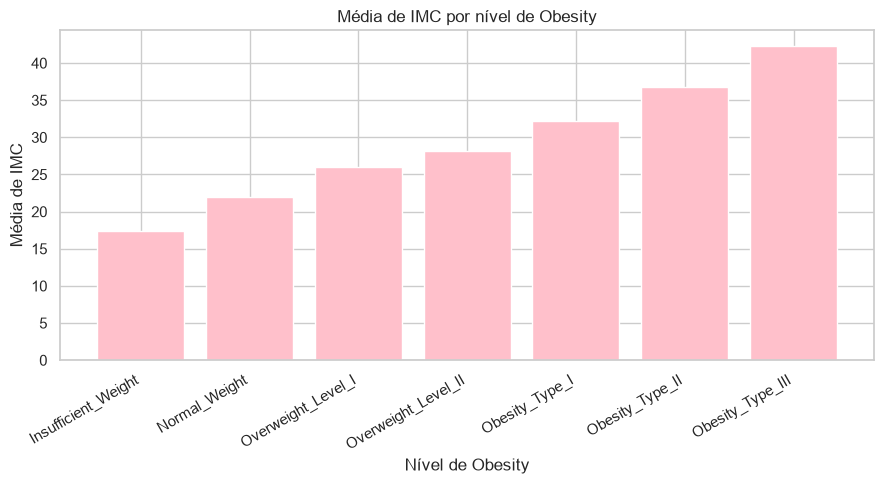

In [25]:
# grafico de barras: IMC medio por nivel de Obesity (mostra a gradacao que da nome
# a variavel-alvo da pergunta de pesquisa)

plt.figure(figsize=(9, 5))
plt.bar(media_imc_por_obesity.index, media_imc_por_obesity.values, color="pink")
plt.title("Média de IMC por nível de Obesity")
plt.xlabel("Nível de Obesity")
plt.ylabel("Média de IMC")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

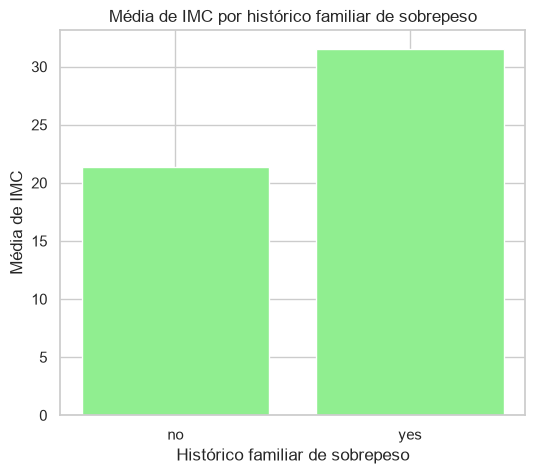

In [26]:
# grafico de barras: IMC medio por historico familiar de sobrepeso, o fator com a
# maior diferenca encontrada no notebook (Conclusao 10)

plt.figure(figsize=(6, 5))
plt.bar(df_med_historico.index, df_med_historico["BMI"], color="lightgreen")
plt.title("Média de IMC por histórico familiar de sobrepeso")
plt.xlabel("Histórico familiar de sobrepeso")
plt.ylabel("Média de IMC")
plt.show()